In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNNBaseline(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 4):
        """
        Default is set for brain tumor:
        - in_channels = 3 (RGB images)
        - num_classes = 4 (glioma, meningioma, notumor, pituitary)
        """
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)

        # Make it independent of input size by pooling down to 2×2
        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        # 64 channels * 2 * 2 = 256
        self.linear1 = nn.Linear(256, 128)
        self.linear2 = nn.Linear(128, num_classes)

        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))
        x = self.pool(x)                      # (B, 64, 2, 2)
        x = x.view(x.size(0), -1)             # (B, 256)

        x = self.act(self.linear1(x))
        x = F.log_softmax(self.linear2(x), dim=-1)
        return x

In [5]:
from matplotlib import pyplot as plt
import numpy as np


def train(train_loader, model, optimizer, epochs):
    device = next(model.parameters()).device
    model.train()
    losses = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        for step, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = F.nll_loss(outputs, labels)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            if step % 50 == 0 and step > 0:
                print(
                    f"[Step {step}] Mean last 50 losses: {np.mean(losses[-50:]):.4f}")

    # plot loss curve
    plt.plot(losses)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.show()


@torch.no_grad()
def evaluate(eval_loader, model):
    device = next(model.parameters()).device
    model.eval()
    accuracies = []

    for inputs, labels in eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        batch_acc = (preds == labels).float().mean().item()
        accuracies.append(batch_acc)

    accuracy = np.mean(accuracies)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    return accuracy

    return accuracy

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5712
Number of testing images: 1311

Epoch 1/10
[Step 50] Mean last 50 losses: 1.2352
[Step 100] Mean last 50 losses: 1.0613
[Step 150] Mean last 50 losses: 0.9992

Epoch 2/10
[Step 50] Mean last 50 losses: 0.8858
[Step 100] Mean last 50 losses: 0.8727
[Step 150] Mean last 50 losses: 0.8451

Epoch 3/10
[Step 50] Mean last 50 losses: 0.6734
[Step 100] Mean last 50 losses: 0.6324
[Step 150] Mean last 50 losses: 0.6161

Epoch 4/10
[Step 50] Mean last 50 losses: 0.5555
[Step 100] Mean last 50 losses: 0.4631
[Step 150] Mean last 50 losses: 0.4613

Epoch 5/10
[Step 50] Mean last 50 losses: 0.4367
[Step 100] Mean last 50 losses: 0.4506
[Step 150] Mean last 50 losses: 0.4223

Epoch 6/10
[Step 50] Mean last 50 losses: 0.3619
[Step 100] Mean last 50 losses: 0.3754
[Step 150] Mean last 50 losses: 0.3952

Epoch 7/10
[Step 50] Mean last 50 losses: 0.3398
[Step 100] Mean last 50 losses: 0.3418
[Step 150] Mean last 5

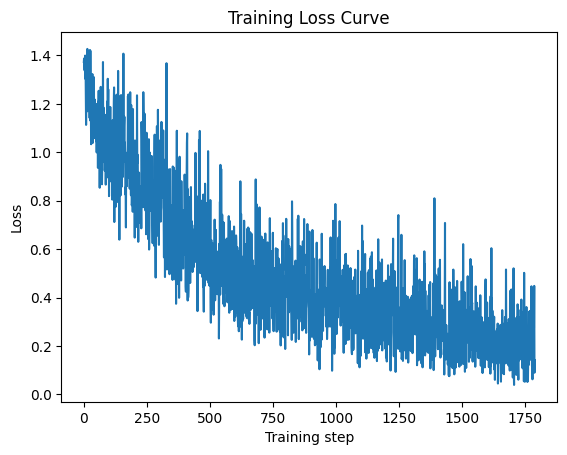

Accuracy: 88.19%


0.881859756097561

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.optim as optim

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # convert to tensor (C,H,W), values in [0,1]
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),                # for 3-channel RGB
        std=(0.5, 0.5, 0.5)
    )
])

train_data = datasets.ImageFolder(
    root="/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Training", transform=transform)
test_data = datasets.ImageFolder(
    root="/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Testing",  transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# should be ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Classes:", train_data.classes)
print("Number of training images:", len(train_data))
print("Number of testing images:", len(test_data))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNBaseline(
    in_channels=3,                     # RGB images
    num_classes=len(train_data.classes)  
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)


train(train_loader, model, optimizer, epochs=10)
evaluate(test_loader, model)

In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=10),      # mild augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5)),
])

In [8]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_data = datasets.ImageFolder(
    root="/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Training", transform=train_transform)
test_data = datasets.ImageFolder(
    root="/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Testing",  transform=test_transform)


train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Classes:", train_data.classes)
print("Number of training images:", len(train_data))  # 5712
print("Number of testing images:", len(test_data))    # 1311

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5712
Number of testing images: 1311


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNNU(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 4):
        """
        Default is set for brain tumor:
        - in_channels = 3 (RGB images)
        - num_classes = 4 (glioma, meningioma, notumor, pituitary)
        """
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2)

        # Make it independent of input size by pooling down to 2×2
        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        # 64 channels * 2 * 2 = 256
        self.linear1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(p=0.5)
        self.linear2 = nn.Linear(128, num_classes)

        self.act = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))

        x = self.pool(x)                  # (B, 64, 2, 2)
        x = x.view(x.size(0), -1)         # (B, 256)

        x = self.act(self.linear1(x))
        x = self.dropout(x)
        x = self.linear2(x)               # raw logits (no log_softmax!)
        return x

In [ ]:

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image

train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = "/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Training"
test_dir = "/Users/trymkyvag/Desktop/Northeastern/Fall 25/CS 6140/Final Project/CS6140FinalProject_Liu_Zhu_Kyvaag/data/Testing"

train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = ImageFolder(root=test_dir, transform=test_transforms)

# --- 3. Création des DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32,
                         shuffle=False, num_workers=2)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(4)
model.to(device)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
num_epochs = 10

best_val_acc = 0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(inputs)
        _, predicted = torch.max(output, 1)
        loss = criterion(output, labels)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_accuracy = correct / total
    train_loss /= len(train_loader)
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)

    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            _, predicted = torch.max(output, 1)
            loss = criterion(output, labels)
            val_loss += loss.item()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_accuracy = correct/total
    val_loss /= len(test_loader)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f} \n"
          f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")

Epoch [1/10] | Train Loss: 1.3857 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [2/10] | Train Loss: 1.3858 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [3/10] | Train Loss: 1.3859 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [4/10] | Train Loss: 1.3857 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [5/10] | Train Loss: 1.3858 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [6/10] | Train Loss: 1.3858 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [7/10] | Train Loss: 1.3858 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089
Epoch [8/10] | Train Loss: 1.3858 | Train Accuracy: 0.2792 
Validation Loss: 1.3833 | Validation Accuracy: 0.3089


KeyboardInterrupt: 